### Load Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

print("Loading raw training and testing data...")
X_train = pd.read_csv('../data/X_train_clean_raw.csv')
X_test = pd.read_csv('../data/X_test_clean_raw.csv')
y_train = pd.read_csv('../data/y_train_clean.csv').values.ravel()
y_test = pd.read_csv('../data/y_test_clean.csv').values.ravel()

feature_names = X_train.columns.tolist()
clinic_names_all = ['Aimolipsies', 'Kardiologiki', 'Nefrologiki']

Loading raw training and testing data...


## STEP 1: Aimolipsies (0) vs Specialized (1 or 2)


 STAGE 1: General Blood Draw vs. Specialized Ward

Stage 1 Accuracy: 81.75%

Classification Report (Stage 1):
              precision    recall  f1-score   support

     General       0.74      0.70      0.72      1567
 Specialized       0.85      0.88      0.87      3135

    accuracy                           0.82      4702
   macro avg       0.80      0.79      0.79      4702
weighted avg       0.82      0.82      0.82      4702



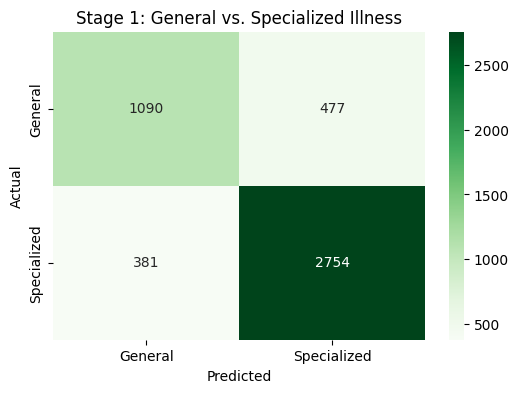

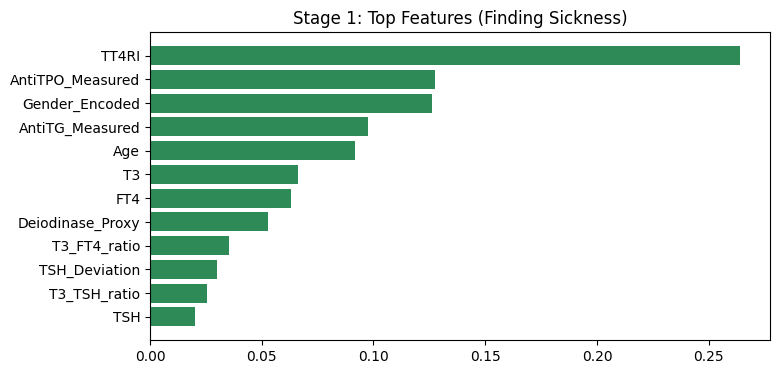

In [22]:
print("\n" + "="*50)
print(" STAGE 1: General Blood Draw vs. Specialized Ward")
print("="*50)

# Create binary labels: 0 = General, 1 = Specialized
y_train_s1 = np.where(y_train == 0, 0, 1) 
y_test_s1 = np.where(y_test == 0, 0, 1)

# Train the model
model_s1 = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_s1.fit(X_train, y_train_s1)

# Evaluate standard predictions
pred_s1 = model_s1.predict(X_test)
print(f"\nStage 1 Accuracy: {accuracy_score(y_test_s1, pred_s1):.2%}")
print("\nClassification Report (Stage 1):")
print(classification_report(y_test_s1, pred_s1, target_names=['General', 'Specialized']))

# Plot Stage 1 Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_s1, pred_s1), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['General', 'Specialized'], yticklabels=['General', 'Specialized'])
plt.title('Stage 1: General vs. Specialized Illness')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plot Stage 1 Feature Importance
plt.figure(figsize=(8, 4))
imp1 = model_s1.feature_importances_
idx1 = np.argsort(imp1)
plt.barh(range(len(idx1)), imp1[idx1], color='seagreen')
plt.yticks(range(len(idx1)), [feature_names[i] for i in idx1])
plt.title('Stage 1: Top Features (Finding Sickness)')
plt.show()

## STEP 2: Kardiologiki (1) vs Nefrologiki (2)


 STAGE 2: Cardiology vs. Nephrology (With Threshold Tuning)

Stage 2 Accuracy (Threshold = 0.58): 74.26%

Classification Report (Stage 2):
              precision    recall  f1-score   support

Kardiologiki       0.74      0.75      0.74      1567
 Nefrologiki       0.75      0.73      0.74      1568

    accuracy                           0.74      3135
   macro avg       0.74      0.74      0.74      3135
weighted avg       0.74      0.74      0.74      3135



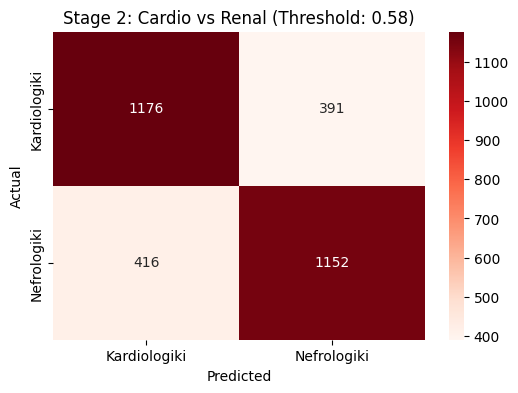

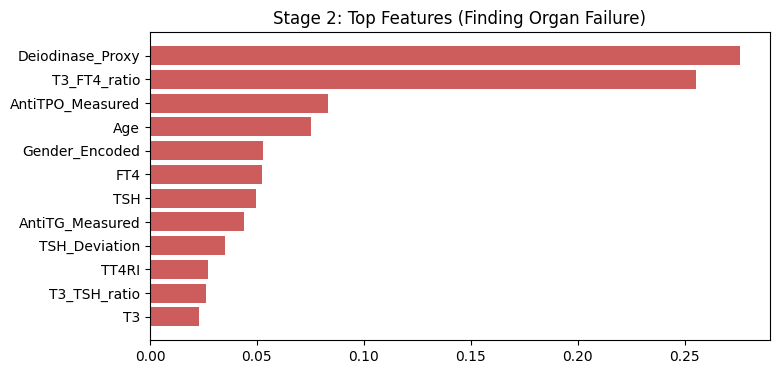

In [23]:
print("\n" + "="*50)
print(" STAGE 2: Cardiology vs. Nephrology (With Threshold Tuning)")
print("="*50)

# Filter only specialized patients
train_mask = (y_train != 0)
test_mask = (y_test != 0)

X_train_s2 = X_train[train_mask]
y_train_s2 = y_train[train_mask] - 1 # Shift labels to 0 (Kardiologiki) and 1 (Nefrologiki)

X_test_s2 = X_test[test_mask]
y_test_s2 = y_test[test_mask] - 1

# Train the model
model_s2 = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_s2.fit(X_train_s2, y_train_s2)

# --- THRESHOLD TUNING ---
# Get probabilities for Class 1 (Nefrologiki)
probs_s2 = model_s2.predict_proba(X_test_s2)[:, 1]

# CHANGE THIS NUMBER: 
# 0.50 is standard. Raising it to ~0.58 forces the AI to pick Cardiology more often.
custom_threshold = 0.58  

# Apply the custom rule
pred_s2_custom = (probs_s2 >= custom_threshold).astype(int)

# Evaluate custom predictions
print(f"\nStage 2 Accuracy (Threshold = {custom_threshold}): {accuracy_score(y_test_s2, pred_s2_custom):.2%}")
print("\nClassification Report (Stage 2):")
print(classification_report(y_test_s2, pred_s2_custom, target_names=['Kardiologiki', 'Nefrologiki']))

# Plot Stage 2 Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_s2, pred_s2_custom), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Kardiologiki', 'Nefrologiki'], yticklabels=['Kardiologiki', 'Nefrologiki'])
plt.title(f'Stage 2: Cardio vs Renal (Threshold: {custom_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plot Stage 2 Feature Importance
plt.figure(figsize=(8, 4))
imp2 = model_s2.feature_importances_
idx2 = np.argsort(imp2)
plt.barh(range(len(idx2)), imp2[idx2], color='indianred')
plt.yticks(range(len(idx2)), [feature_names[i] for i in idx2])
plt.title('Stage 2: Top Features (Finding Organ Failure)')
plt.show()

### Save the model for later use 

In [ ]:
os.makedirs('models', exist_ok=True)
joblib.dump(model_s1, 'models/hierarchical_stage1.pkl')
joblib.dump(model_s2, 'models/hierarchical_stage2.pkl')
print("\n Both Stages successfully trained and saved!")


 Both Stages successfully trained and saved!


## Validation


In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

print("\n" + "="*50)
print(" CROSS-VALIDATION: Checking Model Stability (K-Fold)")
print("="*50)

# Ορίζουμε το Stratified K-Fold (K=5) για να διατηρείται το ποσοστό των κλάσεων
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# Αξιολόγηση Σταδίου 1 (General vs Specialized)
# ==========================================
print("\nRunning 5-Fold CV for Stage 1...")
cv_scores_s1 = cross_val_score(model_s1, X_train, y_train_s1, cv=skf, scoring='accuracy')
print(f"Stage 1 - Scores per fold: {cv_scores_s1}")
print(f"Stage 1 - Mean Accuracy: {np.mean(cv_scores_s1):.2%} (±{np.std(cv_scores_s1):.4f})")

# ==========================================
# Αξιολόγηση Σταδίου 2 (Cardiology vs Nephrology)
# ==========================================
print("\nRunning 5-Fold CV for Stage 2...")
cv_scores_s2 = cross_val_score(model_s2, X_train_s2, y_train_s2, cv=skf, scoring='accuracy')
print(f"Stage 2 - Scores per fold: {cv_scores_s2}")
print(f"Stage 2 - Mean Accuracy: {np.mean(cv_scores_s2):.2%} (±{np.std(cv_scores_s2):.4f})")

print("\nConclusion:")
if np.std(cv_scores_s1) < 0.03 and np.std(cv_scores_s2) < 0.03:
    print("The models are exceptionally stable (Robust)! The standard deviation is less than 3%.")
else:
    print("There is some variance in the data between the Folds.")


 CROSS-VALIDATION: Checking Model Stability (K-Fold)

Running 5-Fold CV for Stage 1...
Stage 1 - Scores per fold: [0.80781499 0.81334751 0.82823717 0.82132412 0.82238766]
Stage 1 - Mean Accuracy: 81.86% (±0.0072)

Running 5-Fold CV for Stage 2...
Stage 2 - Scores per fold: [0.72288676 0.7284689  0.73873155 0.7471081  0.73434384]
Stage 2 - Mean Accuracy: 73.43% (±0.0083)

Conclusion:
The models are exceptionally stable (Robust)! The standard deviation is less than 3%.
